# Project 3 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You will be allocated one of the three themes for part 2 - check announcements on canvas to see which theme is allocated to your group.

You will be working with the Cats and Dogs data set and/or the MNIST data set.

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke". 

The most structured way to do this is Nested CV. That is, an outer K-fold split into training and test and an inner CV-loop for tuning models. However, you can also use repeated random splits into training and testing instead of CV. The benefit of using CV is that the correlation between the outer splits, but a large number of random splits might be more beneficial if you want to compare many models in an outer loop. 


In [1]:
# 

# First the cats and dogs data...
import pandas as pd 

PATHIM = "cnd_large//images.csv" 
PATHLB = "cnd_large//labels.csv"

images_ani = pd.read_csv(PATHIM, sep=",", index_col=0)
labels_ani = pd.read_csv(PATHLB, sep=",", index_col=0)

labels_ani = labels_ani.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images_ani.shape}")
print(f"'labels' size: {labels_ani.shape}")

# Number of classes:
print(f"Classes {labels_ani['label'].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


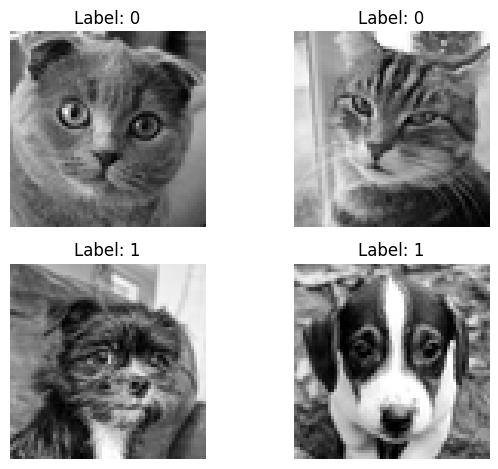

In [2]:
import matplotlib.pyplot as plt
import numpy as np

images_ani = np.array(images_ani)
labels_ani = np.array(labels_ani).ravel()

# Visualize some images (take two from each class):
catidx = np.where(labels_ani == 0)[0]
dogidx = np.where(labels_ani == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = images_ani[idx]
labels_sub = labels_ani[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

In [3]:
# ...then the numbers data
import pandas as pd

PATHIM = "mnist_large//images.csv"
PATHLB = "mnist_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

'images' size: (10000, 784)
'labels' size: (10000, 1)
Classes [0 1 2 3 4 5 6 7 8 9]


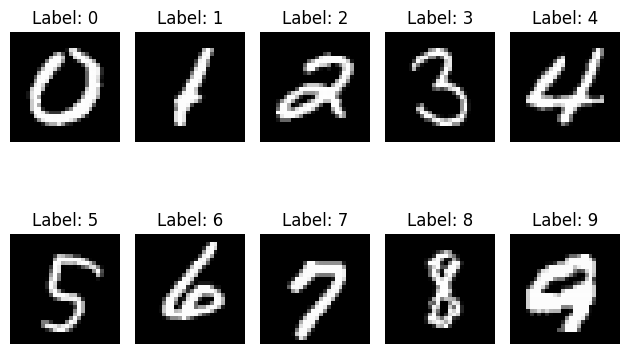

In [4]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

n_images = images.shape[0]

# Visualize the first images in each class
idx = [np.where(labels == i)[0][0] for i in range(10)]
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 5)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(28,28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

# Part 1

*Everyone should do this task.*

For the first part, use the large cats and dogs dataset in order to investigate the effects of varying the sample size (n) on the method.

Use at least 4 classifiers and make sure they span a spectrum from rigid to flexible. 

Compare the Performance: Measure the performance in each method as you decrease the sample size. Also compare the performance across methods.
You should use at least 2 performance metrics, e.g. accuracy, log-loss/cross-entropy, Brier score  ($\frac{1}{N}\sum_{i=1}^N\sum_{k=1}^K (\hat{p}_{ik}-y_{ik})^2$, where $y_{ik}=1$ when observation $i$ belongs to class k, and 0 otherwise), balanced accuracy, F1-macro, etc. The first 3 are more commonly used to compare models through repeated data splits because they mesh well with testing procedures. 

WE WILL TALK ABOUT THE FOLLOWING IN CLASS NEXT WEEK: I recommend you use rank-based tests to compare the models. That is, for each data split, obtain the ranks for all the models. Use the Friedman test to determine if there are any significant differences between model performance. If there is, perform all pairwise tests between models and adjust using the Holm procedure. Now you can either visualize these p-values in a M-by-M heat map (M models) or in a table with equivalent rank groups (e.g. Model 1, Model 3 > Model 2 > Model 4, Model 5). In Python, the \verbatim{scikit_posthocs} package has some of this implemented but you can also code from scratch. The Friedman-allpairsexact test is not available but you can use Nemenyi instead although it is more conservative.  A Bayesian variant allows for another way to create equivalent ranks through - this is implemented in a package called \verbatim{baycomp}. 

Be prepare to explain:
Which method was best and how did you evaluate this?
Did any method suprise you? 
What was your pipeline? 



In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif #?
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

import scikit_posthocs as sp
from scipy.stats import friedmanchisquare

from scipy.stats import wilcoxon
from itertools import combinations

# Nemenyi post-hoc test using scikit_posthocs
import scikit_posthocs as sp
from scipy.stats import rankdata
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import LabelEncoder

import seaborn as sns

In [6]:



B = 5
k = [50, 100, 200]
p_val = 5
random_seeds = [42, 123, 456]
#Function to calculate the new x_train and x_test with fewer patterns

num_trees = [50, 100]

#Models listed from more rigid to more flexible
models = {"LDA": {"params": {}, "results": [], "f1_acc": []},
          "LogisticRegression": {"params": {"classifier__C": [0.5, 1.0, 2.0, 2.5]}, "results": [], "f1_acc": []},
          "RandomForestClassifier": {"params": {"classifier__n_estimators": num_trees}, "results": [], "f1_acc": []},
          "KNN": {"params": {"classifier__n_neighbors": [3, 5, 7]}, "results": [], "f1_acc": []}}



#, "filter__k": k

def classifying(fraction_used, models_loc):
    results = []
    for idx, random_seed in enumerate(random_seeds):

    #X_train_new, x_test_new, x_val_new, y_test_new, y_train_new, y_val_new = get_projected(images, labels, random_seed, train_fraction = 0.6, val_fraction = 0.2)
    
        if fraction_used == 1: 
            X_subsample, y_subsample = images_ani, labels_ani
        else:
            X_subsample, _, y_subsample, _ = train_test_split(images_ani, labels_ani, train_size= fraction_used, stratify=labels_ani, random_state=random_seed)
        X_train, X_test, y_train, y_test = train_test_split(
            X_subsample,
            y_subsample,
            test_size=0.2,
            stratify=y_subsample,
            random_state=random_seed
        )

        #LDA
        pipe_lda = Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LinearDiscriminantAnalysis())
        ])

        #opt_lda = RandomizedSearchCV(
        #    pipe_lda,
        #    param_distributions = models_loc["LDA"]["params"], 
        #    n_iter=10,
        #    cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = 0),
        #    scoring = "f1",
        #    n_jobs=2
        #)
        pipe_lda.fit(X_train, y_train)
        #y_pred = pipe_lda.predict(X_test)
        y_pred_proba = pipe_lda.predict_proba(X_test)
        p = pipe_lda.predict_proba(X_test)[:, 1] #Prob for positive class
        brier_lda = brier_score_loss(y_test, p)
        log_loss_lda = log_loss(y_test, y_pred_proba)
        print(f"Brier score on test set: {brier_lda}")
        print(f"Log loss on test set: {log_loss_lda}")
        #print(opt.cv_results_)
        #print(f"the best optimiser is {pipe_lda.best_estimator_} with score {opt_lda.best_score_} and parameters {opt_lda.best_params_}")
        #final_mask = pipe_lda.best_estimator_.named_steps["filter"].get_support()
        #plt.figure()
        #plt.imshow(final_mask.reshape(64,64), cmap="gray")
        #plt.title("Random Forest selected pixels")
        #plt.show()
        results.append({
            "Fraction": fraction_used,
            "Model": "LDA",
            "Brier": brier_lda,
            "LogLoss": log_loss_lda
        })

        #Logistic regression:
        pipe_log = Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(solver='saga'))
        ])

        opt_log = GridSearchCV(
            pipe_log,
            param_grid = models_loc["LogisticRegression"]["params"], 
            cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = 0),
            scoring = "neg_log_loss",
            n_jobs=2
        )
        opt_log.fit(X_train, y_train)
        #y_pred = opt_log.predict(X_test)
        y_pred_proba = opt_log.best_estimator_.predict_proba(X_test)
        p = opt_log.best_estimator_.predict_proba(X_test)[:, 1] #Prob for positive class
        #f1_log = f1_score(y_test, y_pred)
        brier_log = brier_score_loss(y_test, p)
        log_loss_log = log_loss(y_test, y_pred_proba)
        print(f"Brier score on test set: {brier_log}")
        #print(opt.cv_results_)
        print(f"the best optimiser is {opt_log.best_estimator_} with score {opt_log.best_score_} and parameters {opt_log.best_params_}")
        #final_mask = pipe_lda.best_estimator_.named_steps["filter"].get_support()
        #plt.figure()
        #plt.imshow(final_mask.reshape(64,64), cmap="gray")
        #plt.title("Random Forest selected pixels")
        #plt.show()

        models_loc["LogisticRegression"]["results"].append([opt_log.best_estimator_, opt_log.best_score_, opt_log.best_params_])
        results.append({
            "Fraction": fraction_used,
            "Model": "Logistic",
            "Brier": brier_log,
            "LogLoss": log_loss_log
        })
      
        #Raandom forest

        pipe_random_forest = Pipeline([
            #("filter", SelectKBest(score_func = f_classif)), #filter
            #("embedded", SelectFromModel(LogisticRegression(l1_ratio=1, solver='liblinear', random_state=random_seed), threshold = "median")), #embedded
            ("classifier", RandomForestClassifier(random_state=random_seed))
            ])
    


        #max_depth=10, min_samples_split=10, min_samples_leaf =5,
        #max_features='sqrt', random_state=123, n_jobs = -1
        opt = GridSearchCV(
            pipe_random_forest,
            param_grid = models_loc["RandomForestClassifier"]["params"], 
            cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = 0),
            scoring = "neg_log_loss",
            n_jobs=2
        )
        opt.fit(X_train, y_train)
        #y_pred = opt.predict(X_test)
        y_pred_proba = opt.best_estimator_.predict_proba(X_test)
        p = opt.best_estimator_.predict_proba(X_test)[:, 1] #Prob for positive class
        #f1_rf = f1_score(y_test, y_pred)
        brier_rf = brier_score_loss(y_test, p)
        log_loss_rf =log_loss(y_test, y_pred_proba)
        print(f"Brier score on test set: {brier_rf}")
        #print(opt.cv_results_)
        print(f"the best optimiser is {opt.best_estimator_} with score {opt.best_score_} and parameters {opt.best_params_}")
        #final_mask = opt.best_estimator_.named_steps["filter"].get_support()
        #plt.figure()
        #plt.imshow(final_mask.reshape(64,64), cmap="gray")
        #plt.title("Random Forest selected pixels")
        #plt.show()

        models_loc["RandomForestClassifier"]["results"].append([opt.best_estimator_, opt.best_score_, opt.best_params_])
        results.append({
            "Fraction": fraction_used,
            "Model": "RandomForest",
            "Brier": brier_rf,
            "LogLoss": log_loss_rf
        })
        

        #KNN
        pipe_knn = Pipeline([
            ("scaler", StandardScaler()),
            #("filter", SelectKBest(score_func = f_classif)), #filter
            #("embedded", SelectFromModel(LogisticRegression(l1_ratio=1, solver='liblinear', random_state=random_seed), threshold = "median")), #embedded
            ("classifier", KNeighborsClassifier())
            ])
        opt_knn = RandomizedSearchCV(
            pipe_knn,
            param_distributions = models_loc["KNN"]["params"], 
            n_iter=10,
            cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = 0),
            scoring = "neg_log_loss",
            n_jobs=2
        )
        opt_knn.fit(X_train, y_train)
        #y_pred_knn = opt_knn.predict(X_test)
        y_pred_proba = opt_knn.best_estimator_.predict_proba(X_test)
        p = opt_knn.best_estimator_.predict_proba(X_test)[:, 1] #Prob for positive class
        brier_knn = brier_score_loss(y_test, p)
        log_loss_knn = log_loss(y_test, y_pred_proba)
        print(f"Brier score on test set: {brier_knn}")
        #print(opt_knn.cv_results_)
        print(f"the best optimiser is {opt_knn.best_estimator_} with score {opt_knn.best_score_} and parameters {opt_knn.best_params_}")
        #final_mask_knn = opt_knn.best_estimator_.named_steps["filter"].get_support()
        #plt.figure()
        #plt.imshow(final_mask_knn.reshape(64,64), cmap="gray")
        #plt.title("KNN selected pixels")
        #plt.show()
        models_loc["KNN"]["results"].append((opt_knn.best_estimator_, opt_knn.best_score_, opt_knn.best_params_))
        results.append({
            "Fraction": fraction_used,
            "Model": "KNN",
            "Brier": brier_knn,
            "LogLoss": log_loss_knn
        })

    results_df = pd.DataFrame(results)
    return models_loc, results_df


fractions = [1, 0.8, 0.5, 0.2]

models, results_df_1= classifying(fractions[0], models)
models, results_df_08 = classifying(fractions[1], models)
models, results_df_05 = classifying(fractions[2], models)
models, results_df_02 = classifying(fractions[3], models)

Brier score on test set: 0.2404720558549532
Log loss on test set: 1.3340591347246606


C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Brier score on test set: 0.13339620980969197
the best optimiser is Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(C=0.5, solver='saga'))]) with score -0.49842772616043485 and parameters {'classifier__C': 0.5}
Brier score on test set: 0.11643165000000001
the best optimiser is Pipeline(steps=[('classifier', RandomForestClassifier(random_state=42))]) with score -0.3987550490418373 and parameters {'classifier__n_estimators': 100}


C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Brier score on test set: 0.17944897959183675
the best optimiser is Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', KNeighborsClassifier(n_neighbors=7))]) with score -1.326880922309511 and parameters {'classifier__n_neighbors': 7}
Brier score on test set: 0.25766135957383474
Log loss on test set: 1.4166886708286588


...

Brier score on test set: 0.20153061224489796
the best optimiser is Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', KNeighborsClassifier(n_neighbors=7))]) with score -1.3390917491045677 and parameters {'classifier__n_neighbors': 7}
Brier score on test set: 0.2809304074290652
Log loss on test set: 2.097396740922235


C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Brier score on test set: 0.1690990722411375
the best optimiser is Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(C=0.5, solver='saga'))]) with score -0.536957514286932 and parameters {'classifier__C': 0.5}
Brier score on test set: 0.13860925
the best optimiser is Pipeline(steps=[('classifier', RandomForestClassifier(random_state=456))]) with score -0.4660528060600566 and parameters {'classifier__n_estimators': 100}


C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Brier score on test set: 0.21193877551020407
the best optimiser is Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', KNeighborsClassifier(n_neighbors=7))]) with score -1.1475891412378905 and parameters {'classifier__n_neighbors': 7}


In [7]:
# Combine the four result dataframes created by classifying(...).
# This replaces the old undefined variables brier_1, log_loss_1, and n_methods.
part1_results_df = pd.concat(
    [results_df_1, results_df_08, results_df_05, results_df_02],
    ignore_index=True
)

# The current classifying(...) function does not store the seed, so reconstruct
# the repeated split number from the row order within each Fraction/Model group.
part1_results_df["Repeat"] = (
    part1_results_df
    .groupby(["Fraction", "Model"])
    .cumcount()
)

part1_summary = (
    part1_results_df
    .groupby(["Fraction", "Model"], as_index=False)
    .agg(
        MeanBrier=("Brier", "mean"),
        SdBrier=("Brier", "std"),
        MeanLogLoss=("LogLoss", "mean"),
        SdLogLoss=("LogLoss", "std")
    )
    .sort_values(["Fraction", "MeanLogLoss"], ascending=[False, True])
)

part1_summary.round(4)


,Fraction,Model,MeanBrier,SdBrier,MeanLogLoss,SdLogLoss
15,1.0,RandomForest,0.1161,0.0007,0.3833,0.0022
14,1.0,Logistic,0.1392,0.0077,0.4535,0.0337
13,1.0,LDA,0.2500,0.0087,1.4102,0.0731
12,1.0,KNN,0.1798,0.0023,1.4756,0.1155
11,0.8,RandomForest,0.1207,0.0030,0.3955,0.0052
10,0.8,Logistic,0.1500,0.0065,0.4887,0.0170
8,0.8,KNN,0.1767,0.0090,1.3285,0.3042
9,0.8,LDA,0.2984,0.0173,2.7458,0.2166
7,0.5,RandomForest,0.1229,0.0045,0.4024,0.0087
6,0.5,Logistic,0.1470,0.0010,0.4970,0.0018


In [8]:
# Rank models within each repeated split and sample fraction.
# Lower Brier and lower log-loss are better, so ascending rank is used.
part1_results_df["RankBrier"] = (
    part1_results_df
    .groupby(["Fraction", "Repeat"])["Brier"]
    .rank(ascending=True, method="average")
)

part1_results_df["RankLogLoss"] = (
    part1_results_df
    .groupby(["Fraction", "Repeat"])["LogLoss"]
    .rank(ascending=True, method="average")
)

rank_summary = (
    part1_results_df
    .groupby(["Fraction", "Model"], as_index=False)
    .agg(
        MeanRankBrier=("RankBrier", "mean"),
        MeanRankLogLoss=("RankLogLoss", "mean")
    )
    .sort_values(["Fraction", "MeanRankLogLoss"], ascending=[False, True])
)

friedman_rows = []

for fraction_used in sorted(part1_results_df["Fraction"].unique(), reverse=True):
    subset = part1_results_df[part1_results_df["Fraction"] == fraction_used]

    for metric in ["Brier", "LogLoss"]:
        wide = subset.pivot(index="Repeat", columns="Model", values=metric)
        stat, p_value = friedmanchisquare(
            *[wide[model_name] for model_name in wide.columns]
        )

        friedman_rows.append({
            "Fraction": fraction_used,
            "Metric": metric,
            "FriedmanStatistic": stat,
            "PValue": p_value
        })

friedman_df = pd.DataFrame(friedman_rows)

display(rank_summary.round(4))
display(friedman_df.round(4))


,Fraction,Model,MeanRankBrier,MeanRankLogLoss
15,1.0,RandomForest,1.0,1.0000
14,1.0,Logistic,2.0,2.0000
13,1.0,LDA,4.0,3.3333
12,1.0,KNN,3.0,3.6667
11,0.8,RandomForest,1.0,1.0000
10,0.8,Logistic,2.0,2.0000
8,0.8,KNN,3.0,3.0000
9,0.8,LDA,4.0,4.0000
7,0.5,RandomForest,1.0,1.0000
6,0.5,Logistic,2.0,2.0000


,Fraction,Metric,FriedmanStatistic,PValue
0,1.0,Brier,9.0,0.0293
1,1.0,LogLoss,8.2,0.0421
2,0.8,Brier,9.0,0.0293
3,0.8,LogLoss,9.0,0.0293
4,0.5,Brier,9.0,0.0293
5,0.5,LogLoss,9.0,0.0293
6,0.2,Brier,9.0,0.0293
7,0.2,LogLoss,9.0,0.0293


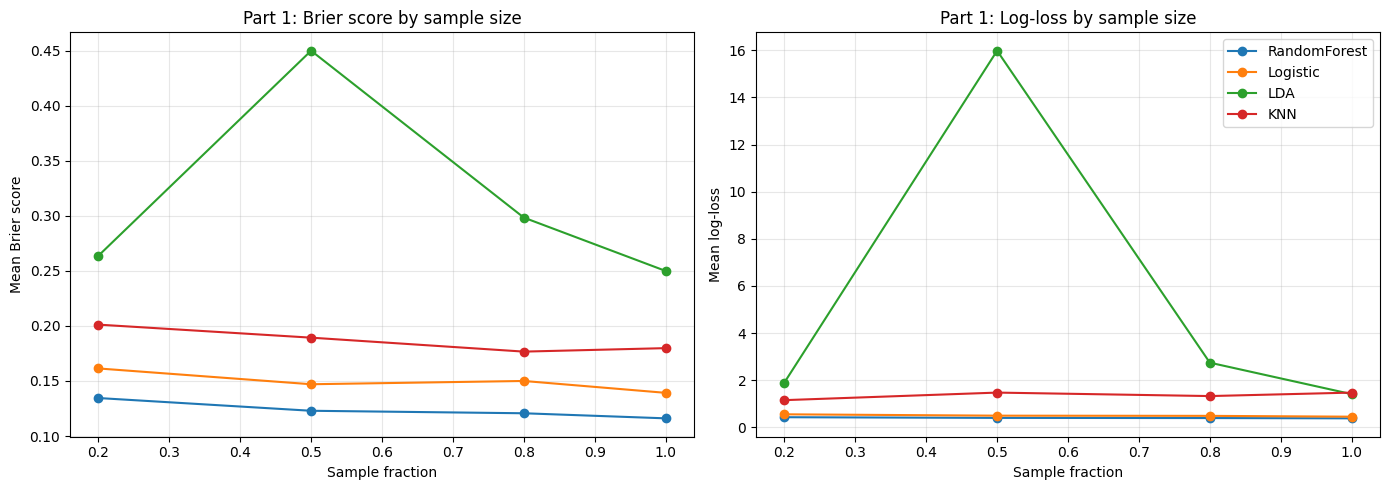

In [9]:
# Plot Brier score and log-loss across sample sizes.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name in part1_summary["Model"].unique():
    model_df = (
        part1_summary[part1_summary["Model"] == model_name]
        .sort_values("Fraction")
    )

    axes[0].plot(
        model_df["Fraction"],
        model_df["MeanBrier"],
        marker="o",
        label=model_name
    )
    axes[1].plot(
        model_df["Fraction"],
        model_df["MeanLogLoss"],
        marker="o",
        label=model_name
    )

axes[0].set_xlabel("Sample fraction")
axes[0].set_ylabel("Mean Brier score")
axes[0].set_title("Part 1: Brier score by sample size")
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Sample fraction")
axes[1].set_ylabel("Mean log-loss")
axes[1].set_title("Part 1: Log-loss by sample size")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


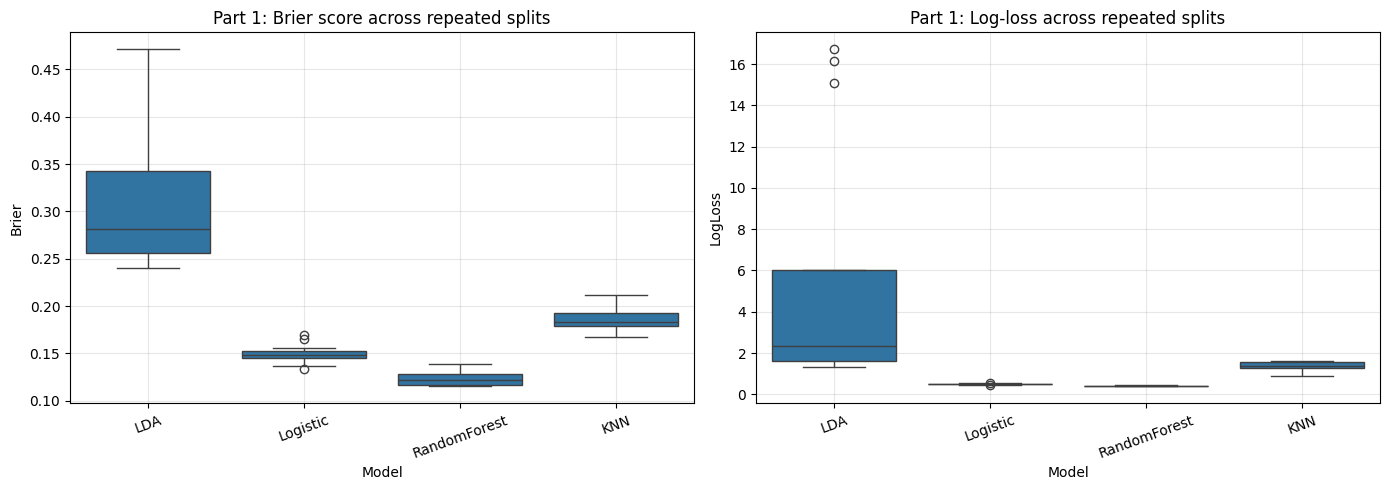

In [10]:
# Boxplots across all repeated splits and sample sizes.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=part1_results_df,
    x="Model",
    y="Brier",
    ax=axes[0]
)
axes[0].set_title("Part 1: Brier score across repeated splits")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(True, alpha=0.3)

sns.boxplot(
    data=part1_results_df,
    x="Model",
    y="LogLoss",
    ax=axes[1]
)
axes[1].set_title("Part 1: Log-loss across repeated splits")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
# Final Part 1 summary. Lower values are better for both Brier score and log-loss.
part1_overall = (
    part1_results_df
    .groupby("Model", as_index=False)
    .agg(
        MeanBrier=("Brier", "mean"),
        SdBrier=("Brier", "std"),
        MeanLogLoss=("LogLoss", "mean"),
        SdLogLoss=("LogLoss", "std"),
        MeanRankBrier=("RankBrier", "mean"),
        MeanRankLogLoss=("RankLogLoss", "mean")
    )
    .sort_values(["MeanLogLoss", "MeanBrier"], ascending=[True, True])
)

display(part1_overall.round(4))

best_part1_model = part1_overall.iloc[0]["Model"]
best_part1_log_loss = part1_overall.iloc[0]["MeanLogLoss"]

print(f"Best overall Part 1 model by mean log-loss: {best_part1_model}")
print(f"Mean log-loss for the best model: {best_part1_log_loss:.3f}")
print("Use the summary table, plots, and rank table to explain whether the ranking changes with sample size.")


,Model,MeanBrier,SdBrier,MeanLogLoss,SdLogLoss,MeanRankBrier,MeanRankLogLoss
3,RandomForest,0.1235,0.0077,0.4032,0.0194,1.0,1.0000
2,Logistic,0.1494,0.0103,0.4983,0.0414,2.0,2.0000
0,KNN,0.1868,0.0124,1.3588,0.2355,3.0,3.1667
1,LDA,0.3155,0.0845,5.5106,6.3463,4.0,3.8333


Best overall Part 1 model by mean log-loss: RandomForest
Mean log-loss for the best model: 0.403
Use the summary table, plots, and rank table to explain whether the ranking changes with sample size.


## Part 2 - Themes
You will be allocated one of the three themes and should perform ***all*** tasks as described in this theme.

### Theme 1 - Imbalance
Use the Cats and Dogs dataset.

Investigate the effects of imbalance on PART 1 - where you create the imbalance. Try with different train, calibration and test sizes. 

Does the model ranking change?

### Theme 2 - Conformal Prediction
Use the MNIST data set.

Select 3 classifiers. Perform conformal prediction. Do you observe similar conformal predictions between the methods? Summarize the conformal predictions. Are certain classes more often to be lumped together in the same set of predictions and does it depend on the classifier used? 

Try with different train, calibration and test sizes. 

### Theme 3 - Mislabeling

Create a mislabeled data set from the digits data by randomly changing the labels for some of the observations. *Note, you should only create mislabels for your training data - the test data should be clean.*

Redo Part 1 in this setting.

Which methods handle the mislabeling OK? Which methods struggle? How does sample size affect this?

You should explore at least 3 levels of mislabeling (some modest, some more severe and some really severe cases), i.e. proportion of mislabeled data. *Please note that your test data should be "clean", i.e. without mislabeling*. For each simulation run, make sure you create a clean and separate data set to estimate prediction performance.

Do the above on 3 levels of data (full data, medium data, small data).

In [12]:
#Theme 3
from sklearn.metrics import accuracy_score, balanced_accuracy_score

def corrupt_training_labels(y_train, noise_rate, random_seed):
    rng = np.random.default_rng(random_seed)
    y_noisy = y_train.copy()
    classes = np.unique(y_train)

    n_noisy = int(len(y_train) * noise_rate)

    if n_noisy == 0:
        return y_noisy

    noisy_idx = rng.choice(len(y_train), size=n_noisy, replace=False)

    for idx in noisy_idx:
        current_label = y_noisy[idx]
        possible_labels = classes[classes != current_label]
        y_noisy[idx] = rng.choice(possible_labels)

    return y_noisy

def get_theme3_models(random_seed):
    num_trees = [50, 100]

    models_theme3 = {
        "LDA": {
            "params": {},
            "results": []
        },
        "LogisticRegression": {
            "params": {
                "classifier__C": [0.5, 1.0, 2.0]
            },
            "results": []
        },
        "RandomForestClassifier": {
            "params": {
                "classifier__n_estimators": num_trees,
                "classifier__max_depth": [None, 20]
            },
            "results": []
        },
        "KNN": {
            "params": {
                "classifier__n_neighbors": [3, 5, 7]
            },
            "results": []
        }
    }

    return models_theme3

In [13]:
def classifying_mislabeled_digits(fraction_used, noise_rate, random_seed):
    models_loc = get_theme3_models(random_seed)
    results = []

    if fraction_used == 1:
        X_subsample = images
        y_subsample = labels
    else:
        X_subsample, _, y_subsample, _ = train_test_split(
            images,
            labels,
            train_size=fraction_used,
            stratify=labels,
            random_state=random_seed
        )

    X_train, X_test, y_train_clean, y_test = train_test_split(
        X_subsample,
        y_subsample,
        test_size=0.2,
        stratify=y_subsample,
        random_state=random_seed
    )

    y_train_noisy = corrupt_training_labels(
        y_train_clean,
        noise_rate=noise_rate,
        random_seed=random_seed + 1000
    )

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=random_seed
    )

    # LDA
    pipe_lda = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LinearDiscriminantAnalysis())
    ])

    pipe_lda.fit(X_train, y_train_noisy)
    y_pred = pipe_lda.predict(X_test)
    y_pred_proba = pipe_lda.predict_proba(X_test)

    results.append({
        "Fraction": fraction_used,
        "NoiseRate": noise_rate,
        "RandomSeed": random_seed,
        "Model": "LDA",
        "Accuracy": accuracy_score(y_test, y_pred),
        "BalancedAccuracy": balanced_accuracy_score(y_test, y_pred),
        "F1Macro": f1_score(y_test, y_pred, average="macro"),
        "Brier": np.mean(np.sum((pd.get_dummies(y_test).values - y_pred_proba) ** 2, axis=1)),
        "LogLoss": log_loss(y_test, y_pred_proba),
        "BestCVScore": np.nan,
        "BestParams": {},
        "TrainSize": len(y_train_noisy),
        "TestSize": len(y_test),
        "MislabeledTrain": int(np.sum(y_train_noisy != y_train_clean))
    })

    # Logistic regression
    pipe_log = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, solver="lbfgs"))
    ])

    opt_log = GridSearchCV(
        pipe_log,
        param_grid=models_loc["LogisticRegression"]["params"],
        cv=cv,
        scoring="f1_macro",
        n_jobs=1
    )

    opt_log.fit(X_train, y_train_noisy)
    y_pred = opt_log.predict(X_test)
    y_pred_proba = opt_log.best_estimator_.predict_proba(X_test)

    models_loc["LogisticRegression"]["results"].append([
        opt_log.best_estimator_,
        opt_log.best_score_,
        opt_log.best_params_
    ])

    results.append({
        "Fraction": fraction_used,
        "NoiseRate": noise_rate,
        "RandomSeed": random_seed,
        "Model": "LogisticRegression",
        "Accuracy": accuracy_score(y_test, y_pred),
        "BalancedAccuracy": balanced_accuracy_score(y_test, y_pred),
        "F1Macro": f1_score(y_test, y_pred, average="macro"),
        "Brier": np.mean(np.sum((pd.get_dummies(y_test).values - y_pred_proba) ** 2, axis=1)),
        "LogLoss": log_loss(y_test, y_pred_proba),
        "BestCVScore": opt_log.best_score_,
        "BestParams": opt_log.best_params_,
        "TrainSize": len(y_train_noisy),
        "TestSize": len(y_test),
        "MislabeledTrain": int(np.sum(y_train_noisy != y_train_clean))
    })

    # Random forest
    pipe_random_forest = Pipeline([
        ("classifier", RandomForestClassifier(random_state=random_seed))
    ])

    opt_rf = GridSearchCV(
        pipe_random_forest,
        param_grid=models_loc["RandomForestClassifier"]["params"],
        cv=cv,
        scoring="f1_macro",
        n_jobs=1
    )

    opt_rf.fit(X_train, y_train_noisy)
    y_pred = opt_rf.predict(X_test)
    y_pred_proba = opt_rf.best_estimator_.predict_proba(X_test)

    models_loc["RandomForestClassifier"]["results"].append([
        opt_rf.best_estimator_,
        opt_rf.best_score_,
        opt_rf.best_params_
    ])

    results.append({
        "Fraction": fraction_used,
        "NoiseRate": noise_rate,
        "RandomSeed": random_seed,
        "Model": "RandomForestClassifier",
        "Accuracy": accuracy_score(y_test, y_pred),
        "BalancedAccuracy": balanced_accuracy_score(y_test, y_pred),
        "F1Macro": f1_score(y_test, y_pred, average="macro"),
        "Brier": np.mean(np.sum((pd.get_dummies(y_test).values - y_pred_proba) ** 2, axis=1)),
        "LogLoss": log_loss(y_test, y_pred_proba),
        "BestCVScore": opt_rf.best_score_,
        "BestParams": opt_rf.best_params_,
        "TrainSize": len(y_train_noisy),
        "TestSize": len(y_test),
        "MislabeledTrain": int(np.sum(y_train_noisy != y_train_clean))
    })

    # KNN
    pipe_knn = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier())
    ])

    opt_knn = GridSearchCV(
        pipe_knn,
        param_grid=models_loc["KNN"]["params"],
        cv=cv,
        scoring="f1_macro",
        n_jobs=1
    )

    opt_knn.fit(X_train, y_train_noisy)
    y_pred = opt_knn.predict(X_test)
    y_pred_proba = opt_knn.best_estimator_.predict_proba(X_test)

    models_loc["KNN"]["results"].append([
        opt_knn.best_estimator_,
        opt_knn.best_score_,
        opt_knn.best_params_
    ])

    results.append({
        "Fraction": fraction_used,
        "NoiseRate": noise_rate,
        "RandomSeed": random_seed,
        "Model": "KNN",
        "Accuracy": accuracy_score(y_test, y_pred),
        "BalancedAccuracy": balanced_accuracy_score(y_test, y_pred),
        "F1Macro": f1_score(y_test, y_pred, average="macro"),
        "Brier": np.mean(np.sum((pd.get_dummies(y_test).values - y_pred_proba) ** 2, axis=1)),
        "LogLoss": log_loss(y_test, y_pred_proba),
        "BestCVScore": opt_knn.best_score_,
        "BestParams": opt_knn.best_params_,
        "TrainSize": len(y_train_noisy),
        "TestSize": len(y_test),
        "MislabeledTrain": int(np.sum(y_train_noisy != y_train_clean))
    })

    results_df = pd.DataFrame(results)
    return models_loc, results_df

Running Theme 3: fraction=1, noise=0.05, seed=42
Running Theme 3: fraction=1, noise=0.05, seed=123
Running Theme 3: fraction=1, noise=0.05, seed=456
Running Theme 3: fraction=1, noise=0.2, seed=42
Running Theme 3: fraction=1, noise=0.2, seed=123
Running Theme 3: fraction=1, noise=0.2, seed=456
Running Theme 3: fraction=1, noise=0.4, seed=42
Running Theme 3: fraction=1, noise=0.4, seed=123
Running Theme 3: fraction=1, noise=0.4, seed=456
Running Theme 3: fraction=0.5, noise=0.05, seed=42
Running Theme 3: fraction=0.5, noise=0.05, seed=123
Running Theme 3: fraction=0.5, noise=0.05, seed=456
Running Theme 3: fraction=0.5, noise=0.2, seed=42
Running Theme 3: fraction=0.5, noise=0.2, seed=123
Running Theme 3: fraction=0.5, noise=0.2, seed=456
Running Theme 3: fraction=0.5, noise=0.4, seed=42
Running Theme 3: fraction=0.5, noise=0.4, seed=123
Running Theme 3: fraction=0.5, noise=0.4, seed=456
Running Theme 3: fraction=0.2, noise=0.05, seed=42
Running Theme 3: fraction=0.2, noise=0.05, seed=1

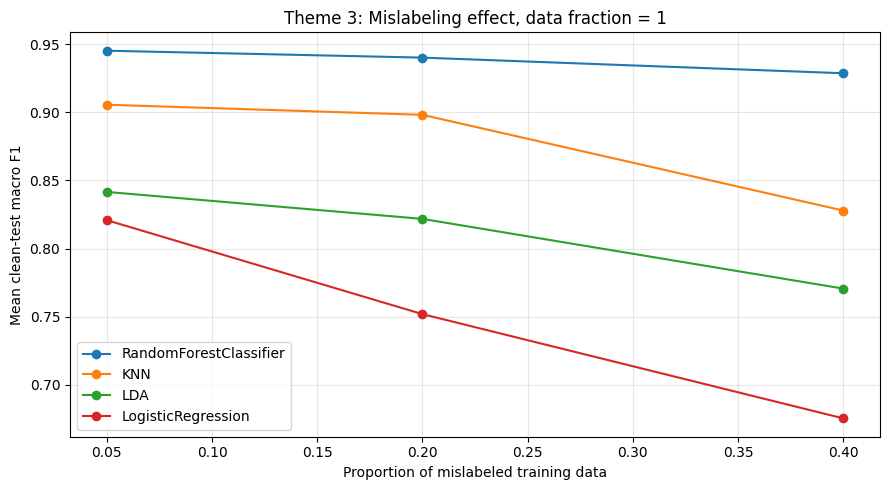

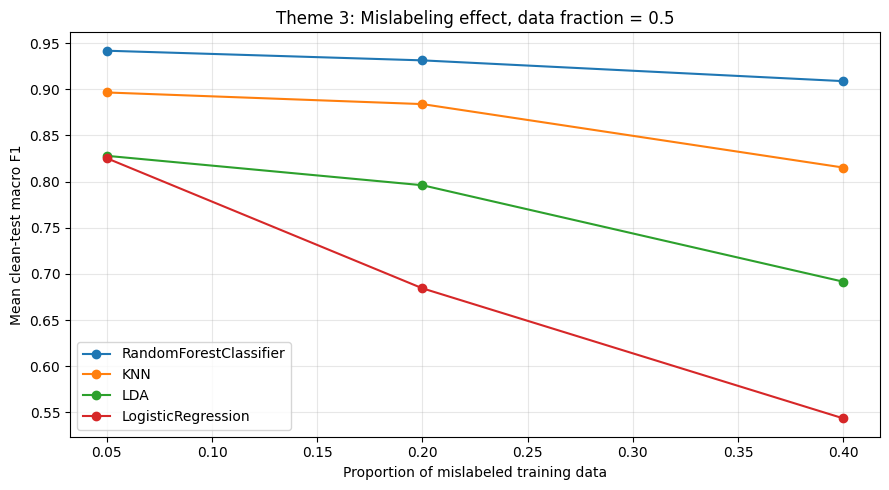

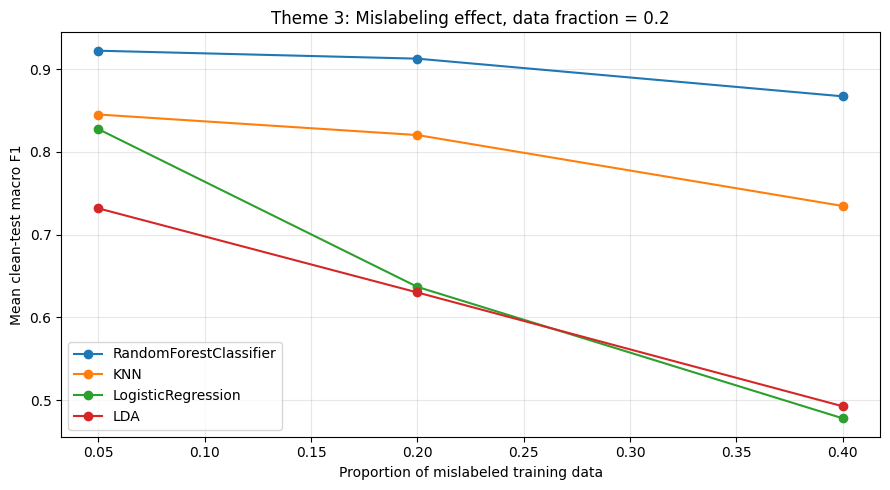

In [14]:
#running it

theme3_fractions = [1, 0.5, 0.2]
theme3_noise_rates = [0.05, 0.20, 0.40]
theme3_random_seeds = [42, 123, 456]

theme3_all_results = []

for fraction_used in theme3_fractions:
    for noise_rate in theme3_noise_rates:
        for random_seed in theme3_random_seeds:
            print(
                f"Running Theme 3: fraction={fraction_used}, "
                f"noise={noise_rate}, seed={random_seed}"
            )

            _, result_df = classifying_mislabeled_digits(
                fraction_used=fraction_used,
                noise_rate=noise_rate,
                random_seed=random_seed
            )

            theme3_all_results.append(result_df)

theme3_results_df = pd.concat(theme3_all_results, ignore_index=True)
theme3_results_df.head()

theme3_summary = (
    theme3_results_df
    .groupby(["Fraction", "NoiseRate", "Model"], as_index=False)
    .agg(
        MeanAccuracy=("Accuracy", "mean"),
        SdAccuracy=("Accuracy", "std"),
        MeanBalancedAccuracy=("BalancedAccuracy", "mean"),
        SdBalancedAccuracy=("BalancedAccuracy", "std"),
        MeanF1Macro=("F1Macro", "mean"),
        SdF1Macro=("F1Macro", "std"),
        MeanBrier=("Brier", "mean"),
        SdBrier=("Brier", "std"),
        MeanLogLoss=("LogLoss", "mean"),
        SdLogLoss=("LogLoss", "std"),
        MeanMislabeledTrain=("MislabeledTrain", "mean")
    )
    .sort_values(["Fraction", "NoiseRate", "MeanF1Macro"], ascending=[False, True, False])
)

theme3_summary.round(4)

for fraction_used in theme3_fractions:
    plot_df = theme3_summary[theme3_summary["Fraction"] == fraction_used]

    plt.figure(figsize=(9, 5))

    for model_name in plot_df["Model"].unique():
        model_df = (
            plot_df[plot_df["Model"] == model_name]
            .sort_values("NoiseRate")
        )

        plt.plot(
            model_df["NoiseRate"],
            model_df["MeanF1Macro"],
            marker="o",
            label=model_name
        )

    plt.xlabel("Proportion of mislabeled training data")
    plt.ylabel("Mean clean-test macro F1")
    plt.title(f"Theme 3: Mislabeling effect, data fraction = {fraction_used}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
#ranking models within each split

theme3_results_df["RankF1Macro"] = (
    theme3_results_df
    .groupby(["RandomSeed", "Fraction", "NoiseRate"])["F1Macro"]
    .rank(ascending=False, method="average")
)

theme3_rank_summary = (
    theme3_results_df
    .groupby(["Fraction", "NoiseRate", "Model"], as_index=False)
    .agg(MeanRank=("RankF1Macro", "mean"))
    .sort_values(["Fraction", "NoiseRate", "MeanRank"])
)

theme3_rank_summary.round(4)

theme3_friedman_results = []

for fraction_used in theme3_fractions:
    for noise_rate in theme3_noise_rates:
        subset = theme3_results_df[
            (theme3_results_df["Fraction"] == fraction_used)
            & (theme3_results_df["NoiseRate"] == noise_rate)
        ]

        wide = subset.pivot(
            index="RandomSeed",
            columns="Model",
            values="F1Macro"
        )

        stat, p_value = friedmanchisquare(
            *[wide[model_name] for model_name in wide.columns]
        )

        theme3_friedman_results.append({
            "Fraction": fraction_used,
            "NoiseRate": noise_rate,
            "FriedmanStatistic": stat,
            "PValue": p_value
        })

theme3_friedman_df = pd.DataFrame(theme3_friedman_results)
theme3_friedman_df.round(4)

theme3_overall = (
    theme3_results_df
    .groupby("Model", as_index=False)
    .agg(
        MeanF1Macro=("F1Macro", "mean"),
        SdF1Macro=("F1Macro", "std"),
        MeanAccuracy=("Accuracy", "mean"),
        MeanBalancedAccuracy=("BalancedAccuracy", "mean"),
        MeanBrier=("Brier", "mean"),
        MeanLogLoss=("LogLoss", "mean"),
        MeanRank=("RankF1Macro", "mean")
    )
    .sort_values(["MeanF1Macro", "MeanRank"], ascending=[False, True])
)

display(theme3_overall.round(4))

best_theme3_model = theme3_overall.iloc[0]["Model"]
best_theme3_f1 = theme3_overall.iloc[0]["MeanF1Macro"]

print(f"Best overall Theme 3 model by mean macro F1: {best_theme3_model}")
print(f"Mean macro F1 for the best model: {best_theme3_f1:.3f}")
print("Use the summary table and plots to explain which model handles mislabeling best.")

,Model,MeanF1Macro,SdF1Macro,MeanAccuracy,MeanBalancedAccuracy,MeanBrier,MeanLogLoss,MeanRank
3,RandomForestClassifier,0.9221,0.0271,0.9224,0.9224,0.3299,0.7736,1.0000
0,KNN,0.8475,0.0544,0.8491,0.8491,0.2890,1.5738,2.0000
1,LDA,0.7338,0.1107,0.7362,0.7362,0.4245,1.8649,3.1852
2,LogisticRegression,0.6937,0.1218,0.6960,0.6960,0.4579,1.2670,3.8148


Best overall Theme 3 model by mean macro F1: RandomForestClassifier
Mean macro F1 for the best model: 0.922
Use the summary table and plots to explain which model handles mislabeling best.
